In [1]:
from google.colab import drive
drive.mount("/content/gdrive")

ModuleNotFoundError: No module named 'google'

In [ ]:
%pwd

'/content'

In [ ]:
%cd /content/gdrive/MyDrive/YOLOv11 projects/Self Driving Car/Lane Detection

/content/gdrive/MyDrive/YOLOv11 projects/Self Driving Car/Lane Detection


In [2]:
%pip install ultralytics
import ultralytics
ultralytics.checks()

Ultralytics 8.3.17  Python-3.12.6 torch-2.5.0+cu118 CUDA:0 (NVIDIA GeForce GTX 1650 Ti, 4096MiB)
Setup complete  (8 CPUs, 15.8 GB RAM, 181.9/281.0 GB disk)


In [ ]:
!yolo segment predict model=yolo11n-seg.pt source='/content/gdrive/MyDrive/YOLOv11 projects/Self Driving Car/Lane Detection/inference/generala-drapsina-street.jpg'

Ultralytics 8.3.37 🚀 Python-3.10.12 torch-2.5.1+cu121 CPU (Intel Xeon 2.20GHz)
YOLO11n-seg summary (fused): 265 layers, 2,868,664 parameters, 0 gradients, 10.4 GFLOPs

image 1/1 /content/gdrive/MyDrive/YOLOv11 projects/Self Driving Car/Lane Detection/inference/generala-drapsina-street.jpg: 448x640 12 cars, 220.6ms
Speed: 5.8ms preprocess, 220.6ms inference, 45.9ms postprocess per image at shape (1, 3, 448, 640)
Results saved to runs/segment/predict
💡 Learn more at https://docs.ultralytics.com/modes/predict


[INFO] - 1:  (371, 550, 3)
[INFO] - 2:  (431, 640, 3)


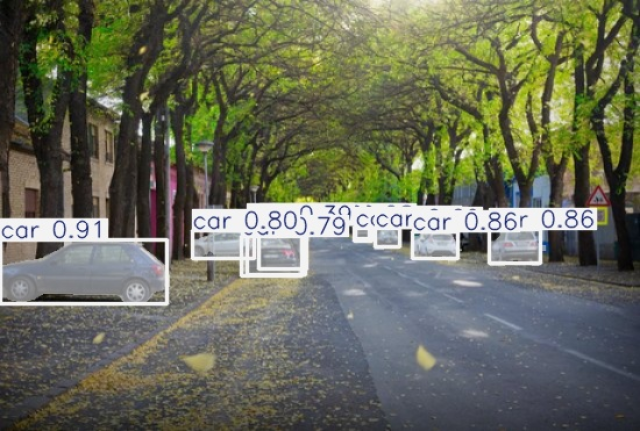

In [ ]:
import cv2
import imutils
from google.colab.patches import cv2_imshow

path = "runs/segment/predict/generala-drapsina-street.jpg"
img = cv2.imread(path)
print("[INFO] - 1: ",img.shape)

img = imutils.resize(img, width=640)
print("[INFO] - 2: ",img.shape)

cv2_imshow(img)

In [ ]:
!yolo segment predict model=yolo11n-seg.pt source='/content/gdrive/MyDrive/YOLOv11 projects/Self Driving Car/Lane Detection/inference/generala-drapsina-street.jpg' hide_labels=True boxes=False

WARNING ⚠️ argument '--hide_labels=True' does not require leading dashes '--', updating to 'hide_labels=True'.
WARNING ⚠️ argument '--boxes=False' does not require leading dashes '--', updating to 'boxes=False'.
WARNING ⚠️ 'hide_labels' is deprecated and will be removed in in the future. Use 'show_labels' instead.
WARNING ⚠️ 'boxes' is deprecated and will be removed in in the future. Use 'show_boxes' instead.
Ultralytics 8.3.37 🚀 Python-3.10.12 torch-2.5.1+cu121 CPU (Intel Xeon 2.20GHz)
YOLO11n-seg summary (fused): 265 layers, 2,868,664 parameters, 0 gradients, 10.4 GFLOPs

image 1/1 /content/gdrive/MyDrive/YOLOv11 projects/Self Driving Car/Lane Detection/inference/generala-drapsina-street.jpg: 448x640 12 cars, 273.5ms
Speed: 10.4ms preprocess, 273.5ms inference, 48.9ms postprocess per image at shape (1, 3, 448, 640)
Results saved to runs/segment/predict2
💡 Learn more at https://docs.ultralytics.com/modes/predict


In [ ]:
!unzip data/dataset.zip -d ./data

Archive:  data/dataset.zip
   creating: ./data/dataset/images/
   creating: ./data/dataset/images/test/
  inflating: ./data/dataset/images/test/156.jpg  
   creating: ./data/dataset/images/train/
  inflating: ./data/dataset/images/train/1.jpg  
  inflating: ./data/dataset/images/train/10.jpg  
  inflating: ./data/dataset/images/train/100.jpg  
  inflating: ./data/dataset/images/train/101.jpg  
  inflating: ./data/dataset/images/train/102.jpg  
  inflating: ./data/dataset/images/train/103.jpg  
  inflating: ./data/dataset/images/train/105.jpg  
  inflating: ./data/dataset/images/train/106.jpg  
  inflating: ./data/dataset/images/train/107.jpg  
  inflating: ./data/dataset/images/train/108.jpg  
  inflating: ./data/dataset/images/train/109.jpg  
  inflating: ./data/dataset/images/train/11.jpg  
  inflating: ./data/dataset/images/train/110.jpg  
  inflating: ./data/dataset/images/train/112.jpg  
  inflating: ./data/dataset/images/train/113.jpg  
  inflating: ./data/dataset/images/train/11

##Train


In [ ]:
%pwd

'/content/gdrive/MyDrive/YOLOv11 projects/Self Driving Car/Lane Detection'

In [ ]:
!yolo segment train model=yolo11l-seg.pt data=data/config.yaml imgsz=640 workers=8 batch=8 device=0 epochs=250 name=yolov11_lane_segmentation

Ultralytics 8.3.38 🚀 Python-3.10.12 torch-2.5.1+cu121 CUDA:0 (Tesla T4, 15102MiB)
engine/trainer: task=segment, mode=train, model=yolo11l-seg.pt, data=data/config.yaml, epochs=250, time=None, patience=100, batch=8, imgsz=640, save=True, save_period=-1, cache=False, device=0, workers=8, project=None, name=yolov11_lane_segmentation, exist_ok=False, pretrained=True, optimizer=auto, verbose=True, seed=0, deterministic=True, single_cls=False, rect=False, cos_lr=False, close_mosaic=10, resume=False, amp=True, fraction=1.0, profile=False, freeze=None, multi_scale=False, overlap_mask=True, mask_ratio=4, dropout=0.0, val=True, split=val, save_json=False, save_hybrid=False, conf=None, iou=0.7, max_det=300, half=False, dnn=False, plots=True, source=None, vid_stride=1, stream_buffer=False, visualize=False, augment=False, agnostic_nms=False, classes=None, retina_masks=False, embed=None, show=False, save_frames=False, save_txt=False, save_conf=False, save_crop=False, show_labels=True, show_conf=True

In [ ]:
!yolo segment train model=runs/segment/yolov11_lane_segmentation/weights/last.pt resume=True

New https://pypi.org/project/ultralytics/8.3.38 available 😃 Update with 'pip install -U ultralytics'
Ultralytics 8.3.37 🚀 Python-3.10.12 torch-2.5.1+cu121 CUDA:0 (Tesla T4, 15102MiB)
engine/trainer: task=segment, mode=train, model=runs/segment/yolov11_lane_segmentation2/weights/last.pt, data=data/config.yaml, epochs=150, time=None, patience=100, batch=8, imgsz=640, save=True, save_period=-1, cache=False, device=0, workers=8, project=None, name=yolov11_lane_segmentation2, exist_ok=False, pretrained=True, optimizer=auto, verbose=True, seed=0, deterministic=True, single_cls=False, rect=False, cos_lr=False, close_mosaic=10, resume=runs/segment/yolov11_lane_segmentation2/weights/last.pt, amp=True, fraction=1.0, profile=False, freeze=None, multi_scale=False, overlap_mask=True, mask_ratio=4, dropout=0.0, val=True, split=val, save_json=False, save_hybrid=False, conf=None, iou=0.7, max_det=300, half=False, dnn=False, plots=True, source=None, vid_stride=1, stream_buffer=False, visualize=False, a

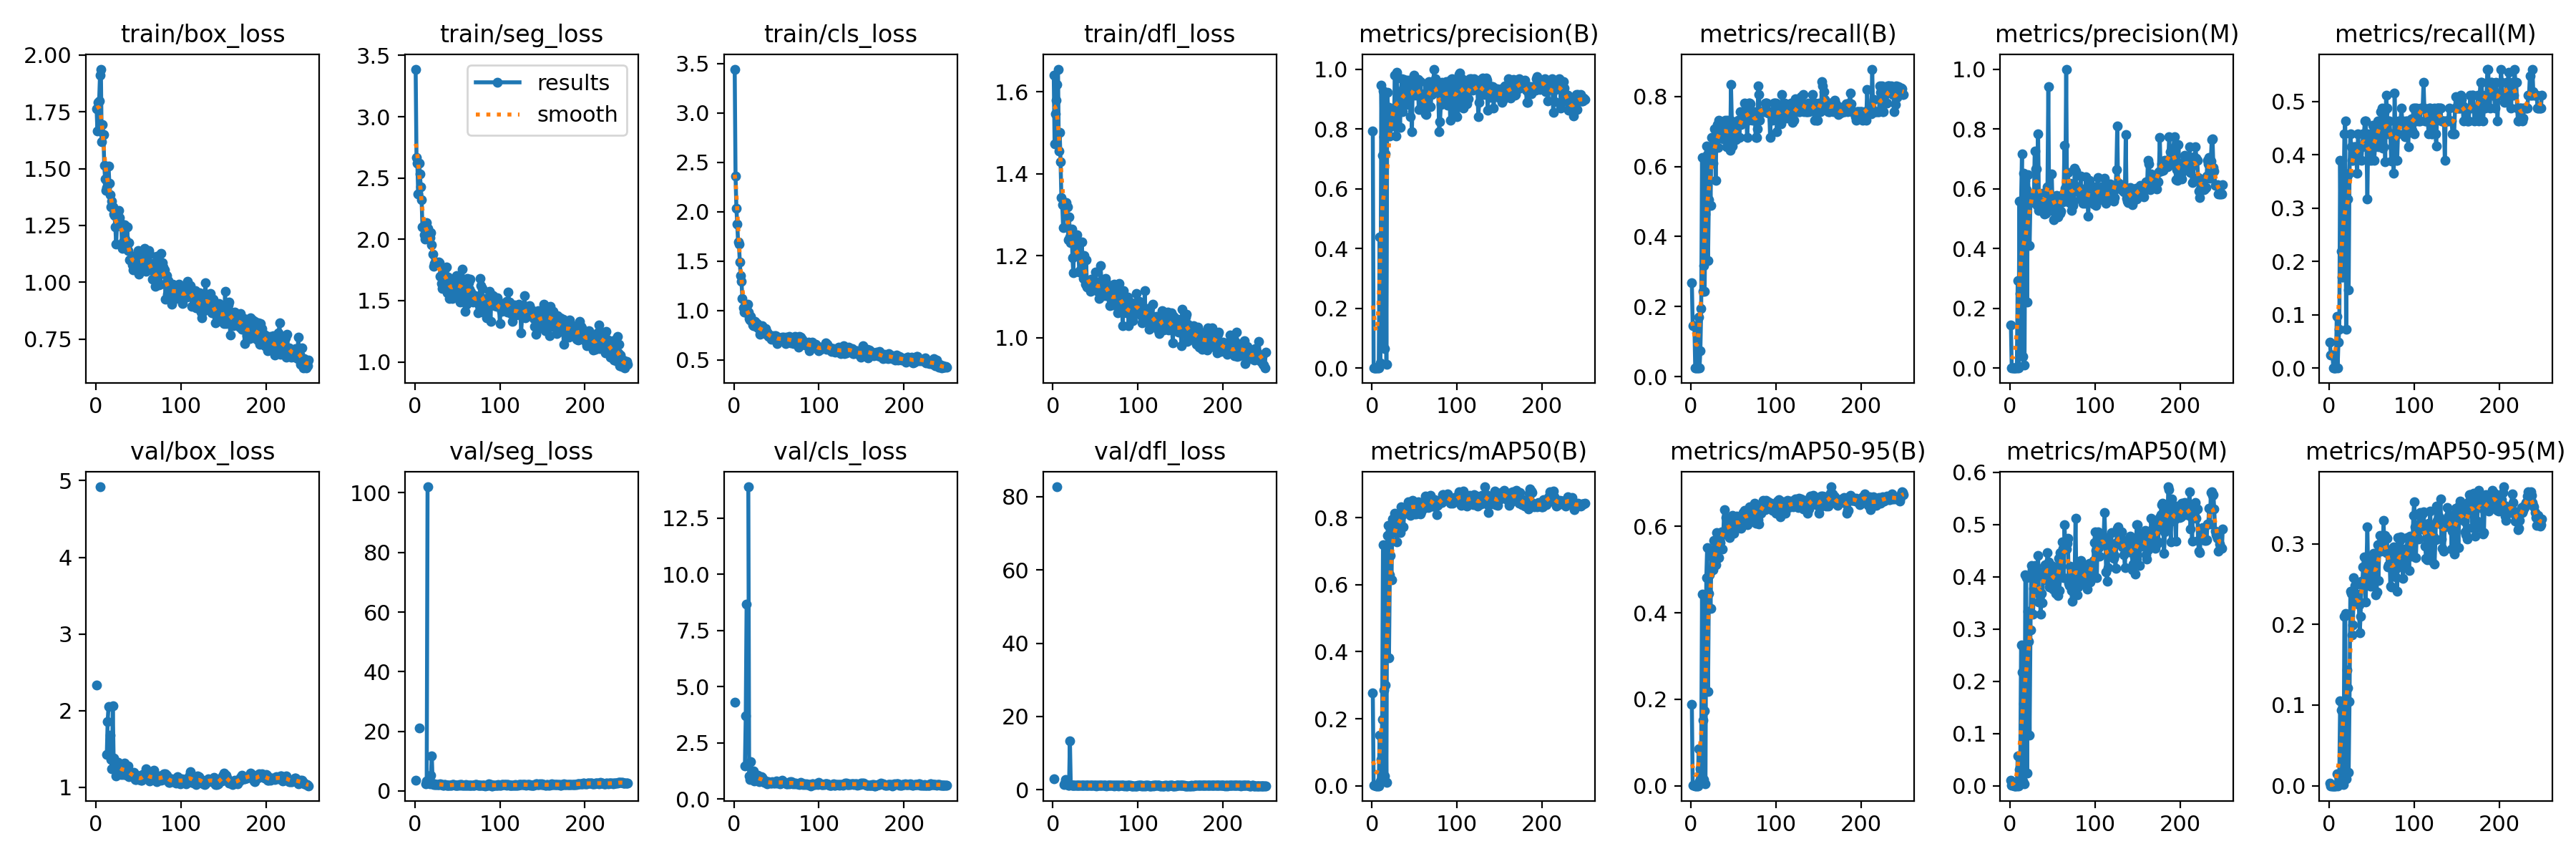

In [ ]:
import cv2
import imutils
from google.colab.patches import cv2_imshow


img_path = "runs/segment/yolov11_lane_segmentation/results.png"
img = cv2.imread(img_path)

cv2_imshow(img)

#Predıct - CLI


In [ ]:
!yolo segment predict model="runs/segment/yolov11_lane_segmentation/weights/best.pt" source= "inference/test images/0.jpg"  show_labels=True show_boxes=False

WARNING ⚠️ 'hide_labels' is deprecated and will be removed in in the future. Use 'show_labels' instead.
WARNING ⚠️ 'boxes' is deprecated and will be removed in in the future. Use 'show_boxes' instead.
Ultralytics 8.3.38 🚀 Python-3.10.12 torch-2.5.1+cu121 CUDA:0 (Tesla T4, 15102MiB)
YOLO11l-seg summary (fused): 491 layers, 27,585,363 parameters, 0 gradients, 141.9 GFLOPs

image 1/1 /content/gdrive/MyDrive/YOLOv11 projects/Self Driving Car/Lane Detection/inference/test images/0.jpg: 384x640 7 lanes, 170.9ms
Speed: 13.1ms preprocess, 170.9ms inference, 1175.4ms postprocess per image at shape (1, 3, 384, 640)
Results saved to runs/segment/predict
💡 Learn more at https://docs.ultralytics.com/modes/predict


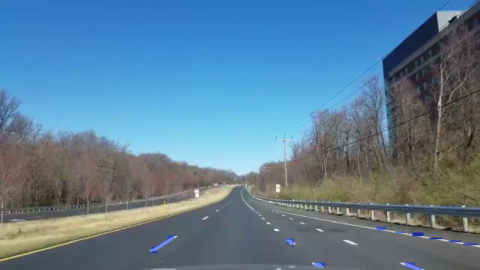

In [ ]:
import cv2
import imutils
from google.colab.patches import cv2_imshow

path="runs/segment/predict/0.jpg"

img=cv2.imread(path)

img=imutils.resize(img,width=480)

cv2_imshow(img)


[INFO]... (720, 1280, 3)

0: 640x640 2 lanes, 60.8ms
Speed: 1.7ms preprocess, 60.8ms inference, 1.8ms postprocess per image at shape (1, 3, 640, 640)
Results saved to runs/segment/predict3


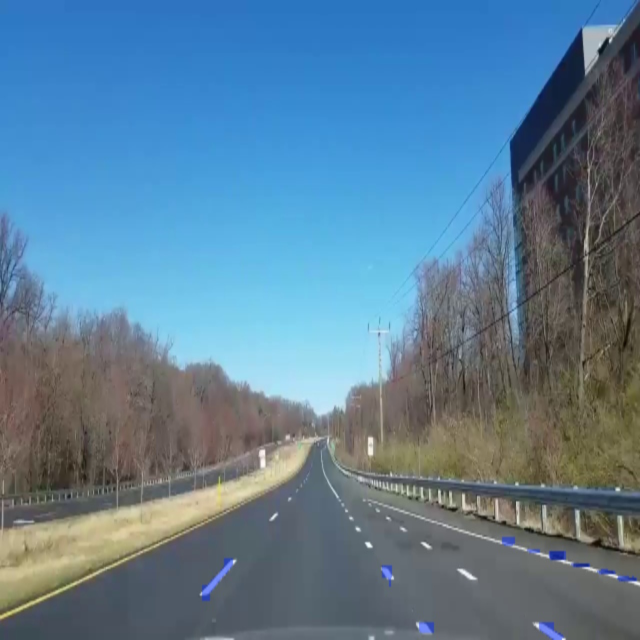

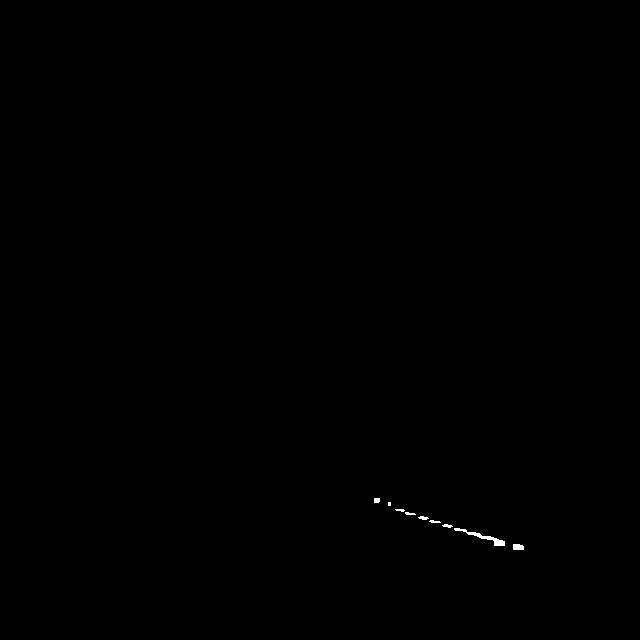

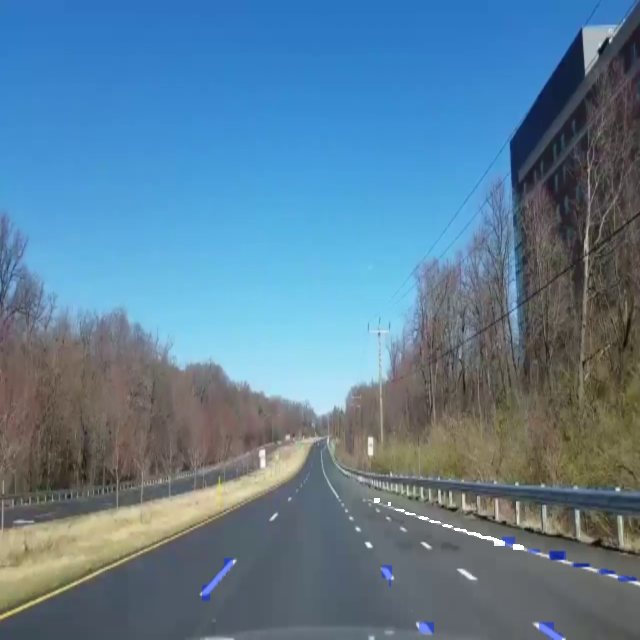

In [ ]:
import cv2
import torch
import imutils

import numpy as np
from ultralytics import YOLO

img_path="runs/segment/predict/0.jpg"

model_path="runs/segment/yolov11_lane_segmentation/weights/best.pt"

img=cv2.imread(img_path)
print("[INFO]...",img.shape)

img = cv2.resize(img, (640,640))

model=YOLO(model_path) #modelimin imgsz'ı 640 olduğu için yeniden boyutlandırma gerek.

results=model.predict(source=img.copy(),save=True, save_txt=False, stream=True)

for result in results:
  #Modelin ürettiği maske sonuçlarını (result.masks) CPU belleğine taşır.
  #Bu işlem, GPU belleğinde yer alan tensorleri işlemeye hazırlamak için yapılır.
  masks=result.masks.data.cpu()
  #Modelin tahmin ettiği nesne sınır kutularını (bounding boxes) CPU belleğine taşır.
  boxes=result.boxes.data.cpu()
  #boxes değişkeninin 6. sütunundaki veriyi alır ([:, 5])
  #Nesne algılama modellerinde, kutular genellikle şu yapıda olur:
  #İlk 4 sütun: Kutunun koordinatları (x_min, y_min, x_max, y_max).
  #5. sütun: Algılanan sınıfın etiketi (ör. "yol", "araba", "insan").
  #6. sütun: Algılama güven puanı (confidence score).
  clss=boxes[:, 5]
  #clss değişkeninde 0 değerine sahip olan (örneğin, "yol" sınıfı olarak etiketlenmiş) öğelerin indekslerini bulur.
  road_indices = np.where(clss == 0)[0]

  lane_masks=masks[road_indices]

  lane_mask = torch.any(lane_masks, dim=0).int()*255
  lane_mask = lane_mask.cpu().numpy()
  lane_mask = lane_mask.astype(np.uint8)

lane_mask_color = cv2.cvtColor(lane_mask, cv2.COLOR_GRAY2BGR)
result_img = cv2.addWeighted(img, 1, lane_mask_color, 0.5, 0)

cv2_imshow(img)
cv2_imshow(lane_mask)
cv2_imshow(result_img)







In [22]:
%pwd

'/content/gdrive/MyDrive/YOLOv11 projects/Self Driving Car/Lane Detection'

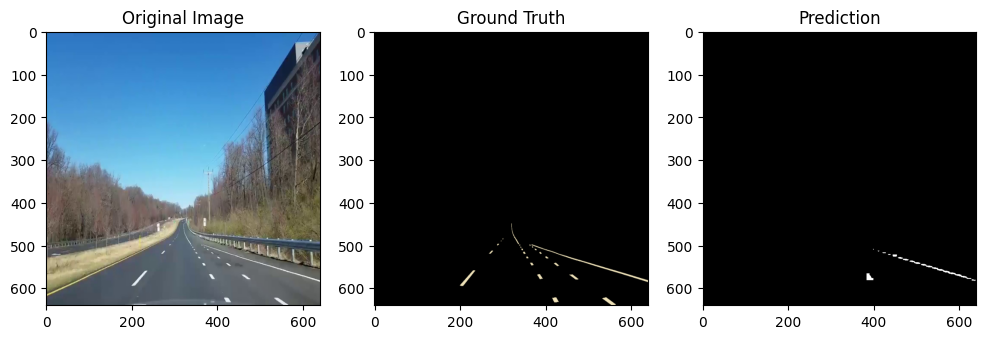

In [24]:
import matplotlib.pyplot as plt


img_path = "inference/test images/0.jpg"
img = cv2.imread(img_path) # BGR
img = cv2.resize(img, (640,640))
img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)


ground_truth_path = "inference/test images/ground_truth/0.png"
ground_truth = cv2.imread(ground_truth_path)
ground_truth = cv2.resize(ground_truth, (640,640))


plt.figure(figsize=(12,6))

plt.subplot(131)
plt.imshow(img)
plt.title('Original Image')


plt.subplot(132)
plt.imshow(ground_truth) # RGB
plt.title('Ground Truth')

plt.subplot(133)
plt.imshow(lane_mask, cmap="gray")
plt.title('Prediction')

plt.show()

In [26]:
!yolo predict model="runs/segment/yolov11_lane_segmentation/weights/best.pt" source="inference/road.mp4" show_labels=false show_boxes=false

Ultralytics 8.3.38 🚀 Python-3.10.12 torch-2.5.1+cu121 CUDA:0 (Tesla T4, 15102MiB)
YOLO11l-seg summary (fused): 491 layers, 27,585,363 parameters, 0 gradients, 141.9 GFLOPs

video 1/1 (frame 1/891) /content/gdrive/MyDrive/YOLOv11 projects/Self Driving Car/Lane Detection/inference/road.mp4: 384x640 3 lanes, 82.9ms
video 1/1 (frame 2/891) /content/gdrive/MyDrive/YOLOv11 projects/Self Driving Car/Lane Detection/inference/road.mp4: 384x640 2 lanes, 39.7ms
video 1/1 (frame 3/891) /content/gdrive/MyDrive/YOLOv11 projects/Self Driving Car/Lane Detection/inference/road.mp4: 384x640 3 lanes, 39.6ms
video 1/1 (frame 4/891) /content/gdrive/MyDrive/YOLOv11 projects/Self Driving Car/Lane Detection/inference/road.mp4: 384x640 3 lanes, 39.6ms
video 1/1 (frame 5/891) /content/gdrive/MyDrive/YOLOv11 projects/Self Driving Car/Lane Detection/inference/road.mp4: 384x640 3 lanes, 39.6ms
video 1/1 (frame 6/891) /content/gdrive/MyDrive/YOLOv11 projects/Self Driving Car/Lane Detection/inference/road.mp4: 384x6